In [1]:
from trade_lab.charts import (
    FrontWeekATMIV,
    AverageTrueRange,
    GEXSlope,
    PriceVolScatter,
    ZeroGammaMigration,
)

## PriceVolScatter

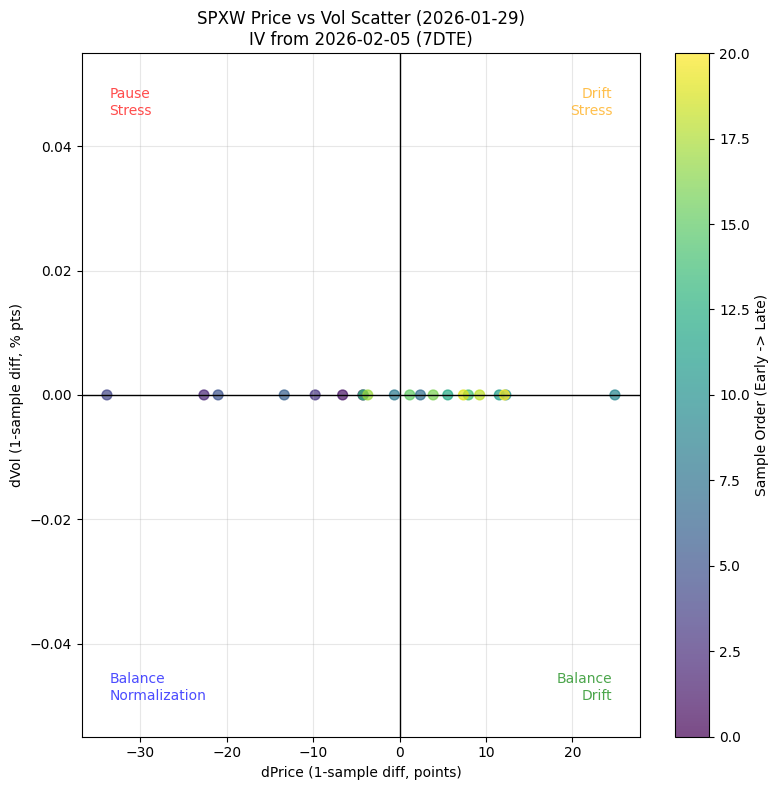

In [9]:
price_vol_scat = PriceVolScatter(symbol="SPXW", sample_date="2026-01-29", data_dir="../data")
price_vol_scat.load_data()
fig, ax = price_vol_scat.plot()

## ZeroGammaMigration

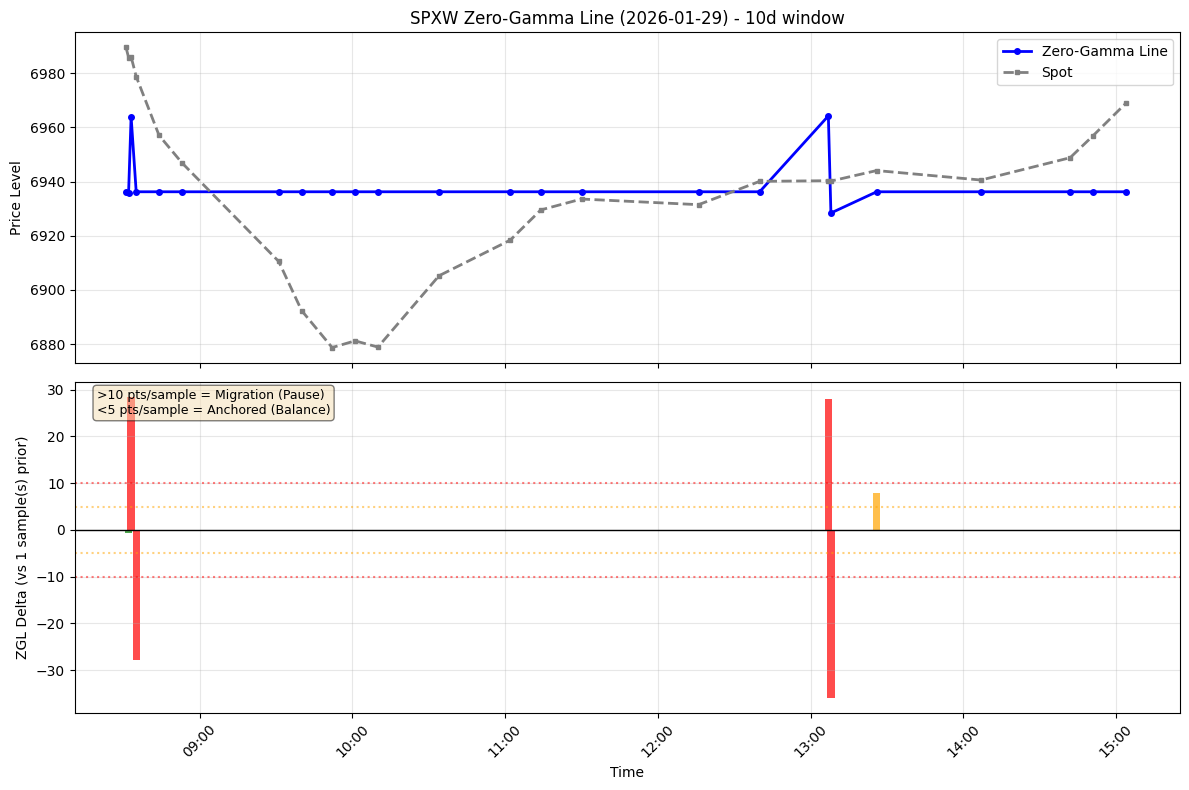

In [7]:
z_gamma_mig = ZeroGammaMigration(symbol="SPXW", sample_date="2026-01-29", data_dir="../data")
z_gamma_mig.load_data()
fig, ax = z_gamma_mig.plot()

## FrontWeekATMIV

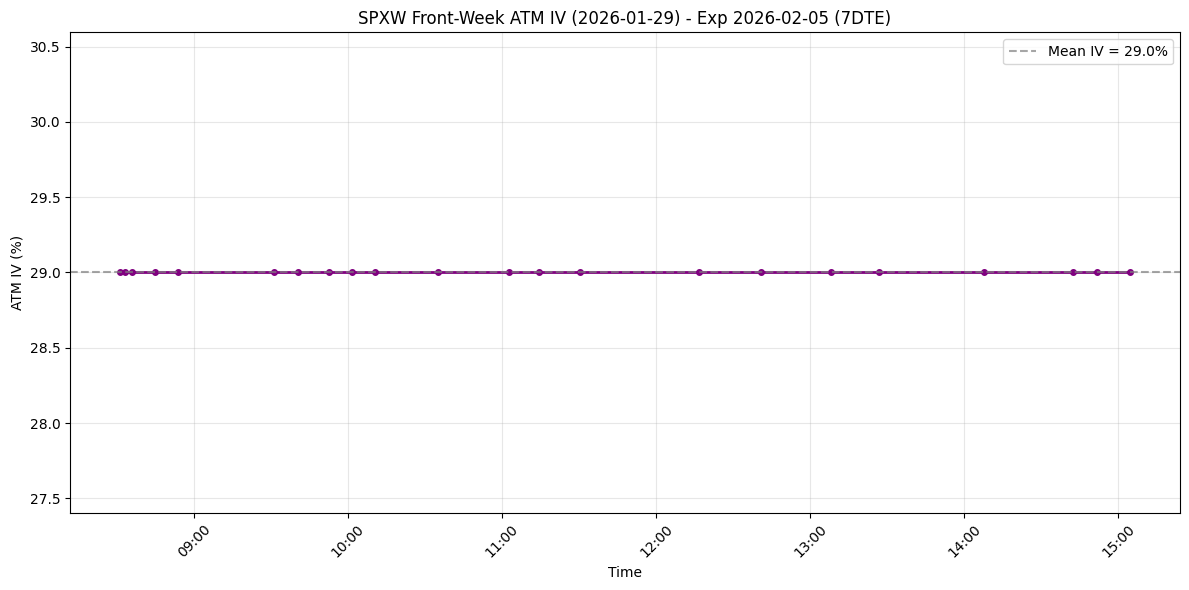

In [5]:
front_week_atm_iv = FrontWeekATMIV(symbol="SPXW", sample_date="2026-01-29", data_dir="../data")
front_week_atm_iv.load_data()
fig, ax = front_week_atm_iv.plot()

## GEXSlope

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'SPXW GEX Slope (2026-01-29) - 10d expirations, ±50pt window, lookback=1'}, xlabel='Time', ylabel='GEX Delta (vs 1 sample(s) prior)'>)

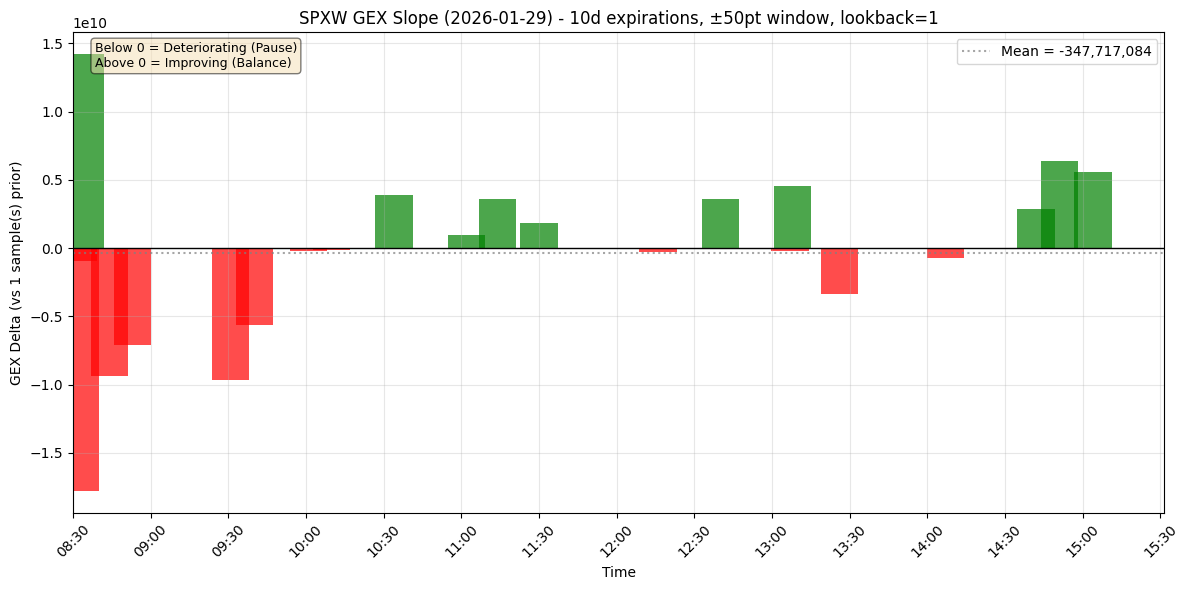

In [2]:
gex_slope = GEXSlope(
    symbol="SPXW",
    sample_date="2026-01-29",
    days_out=10,
    strike_window=50,
    data_dir="../data",
    debug=False,
)
gex_slope.load_data()
gex_slope.plot()

## Average True Range

Searching for OHLC CSV file with pattern: SPX_5_min_2026-01-29.csv
Loading OHLC data from ../data/SPX_5_min_2026-01-29.csv
Calculated ATR with period 10
ATR range: 4.60 - 16.01


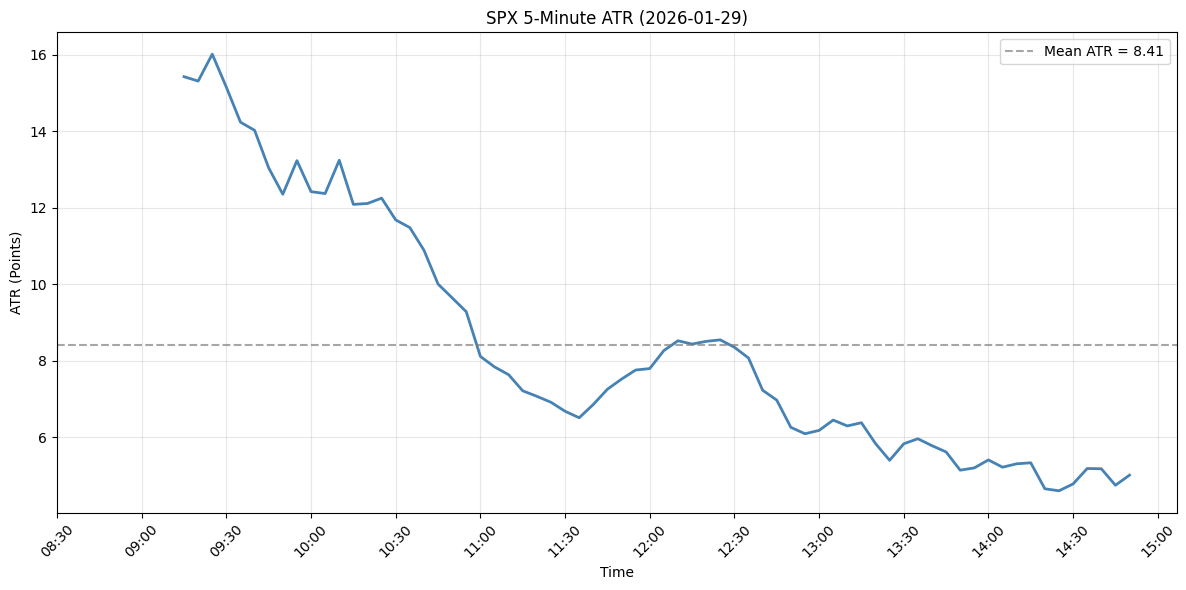

In [15]:
atr = AverageTrueRange(
    symbol="SPX", date="2026-01-29", interval=5, atr_period=10, data_dir="../data", debug=True
)
atr.load_data()
fig, ax = atr.plot()

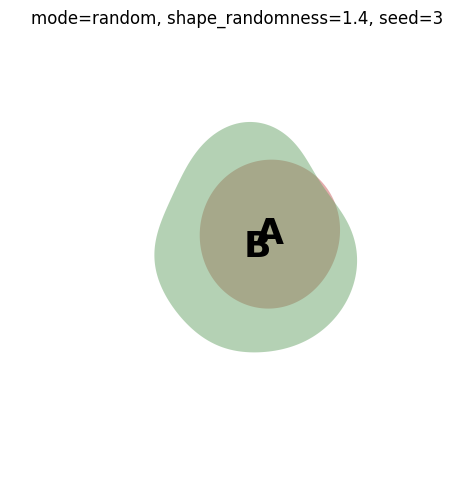

In [10]:
"""
Random "blob" generator with:
- No blob borders (no outlines)
- Parameterized overlap: "overlap", "separate", or "random"
- Randomized blob shapes (by mixing multiple mini-centers per blob)

Dependencies:
  pip install numpy matplotlib scikit-learn
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity


def make_mixture_blob(
    rng: np.random.Generator,
    n: int,
    center: tuple[float, float],
    shape_jitter: float = 1.0,
    n_components_range=(2, 5),
    component_spread=(0.15, 0.9),
):
    """
    Create an organic blob by sampling from a mixture of small Gaussians
    whose means are jittered around `center`.

    shape_jitter controls how "lumpy" the blob is:
      - small -> smoother, rounder
      - larger -> more irregular
    """
    k = rng.integers(n_components_range[0], n_components_range[1] + 1)
    weights = rng.random(k)
    weights /= weights.sum()
    counts = rng.multinomial(n, weights)

    X_parts = []
    for i in range(k):
        # mini-center jittered around the main center
        angle = rng.uniform(0, 2 * np.pi)
        radius = rng.uniform(0.0, shape_jitter)
        mu = np.array(center) + radius * np.array([np.cos(angle), np.sin(angle)])

        # random covariance scale per component
        sd = rng.uniform(component_spread[0], component_spread[1])
        # optional anisotropy / rotation
        a = rng.uniform(0.5, 1.8)
        b = rng.uniform(0.5, 1.8)
        theta = rng.uniform(0, 2 * np.pi)
        R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
        S = np.diag([(sd * a) ** 2, (sd * b) ** 2])
        cov = R @ S @ R.T

        Xi = rng.multivariate_normal(mu, cov, size=counts[i])
        X_parts.append(Xi)

    return np.vstack(X_parts)


def kde_grid(X, bounds, gridsize=260, bandwidth=0.55):
    xmin, xmax, ymin, ymax = bounds
    xs = np.linspace(xmin, xmax, gridsize)
    ys = np.linspace(ymin, ymax, gridsize)
    xx, yy = np.meshgrid(xs, ys)
    grid = np.c_[xx.ravel(), yy.ravel()]

    kde = KernelDensity(bandwidth=bandwidth, kernel="gaussian")
    kde.fit(X)
    dens = np.exp(kde.score_samples(grid)).reshape(gridsize, gridsize)
    return xx, yy, dens


def draw_blob_fill(
    ax,
    X,
    color,
    alpha=0.8,
    bandwidth=0.55,
    level_quantile=0.83,
    zorder=2,
):
    # bounds with padding
    pad = 2.0
    xmin, ymin = X.min(axis=0) - pad
    xmax, ymax = X.max(axis=0) + pad
    xx, yy, dens = kde_grid(X, bounds=(xmin, xmax, ymin, ymax), bandwidth=bandwidth)

    level = np.quantile(dens, level_quantile)
    # Fill only; no outline/border
    ax.contourf(
        xx,
        yy,
        dens,
        levels=[level, dens.max()],
        colors=[color],
        alpha=alpha,
        antialiased=True,
        zorder=zorder,
    )


def choose_centers(rng, mode="overlap", base_sep=2.2):
    """
    Returns two centers (cx1, cy1), (cx2, cy2) based on overlap mode.

    mode:
      - "overlap": close centers -> lots of overlap
      - "separate": far centers -> little/no overlap
      - "random": random distance and direction
    """
    c1 = np.array([0.0, 0.0])

    if mode == "overlap":
        dist = rng.uniform(0.6, 1.4)
    elif mode == "separate":
        dist = rng.uniform(3.3, 5.0)
    elif mode == "random":
        dist = rng.uniform(0.6, 5.0)
    else:
        raise ValueError("mode must be 'overlap', 'separate', or 'random'")

    angle = rng.uniform(0, 2 * np.pi)
    c2 = c1 + dist * np.array([np.cos(angle), np.sin(angle)])
    return tuple(c1), tuple(c2)


def plot_blobs(
    seed=0,
    mode="overlap",  # "overlap" | "separate" | "random"
    shape_randomness=1.2,  # higher -> lumpier shapes
    nA=1100,
    nB=900,
    bandwidth=0.60,
    level_quantile=0.83,
    show_points=False,
):
    rng = np.random.default_rng(seed)

    cA, cB = choose_centers(rng, mode=mode)

    A = make_mixture_blob(
        rng,
        n=nA,
        center=cA,
        shape_jitter=shape_randomness,
        n_components_range=(2, 6),
        component_spread=(0.10, 0.85),
    )
    B = make_mixture_blob(
        rng,
        n=nB,
        center=cB,
        shape_jitter=shape_randomness,
        n_components_range=(2, 6),
        component_spread=(0.10, 0.85),
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)  # remove chart border too (optional)

    # Draw fills (no blob borders)
    draw_blob_fill(
        ax,
        A,
        color="#c85a5a",
        alpha=0.50,
        bandwidth=bandwidth,
        level_quantile=level_quantile,
        zorder=2,
    )
    draw_blob_fill(
        ax,
        B,
        color="#6aa56a",
        alpha=0.50,
        bandwidth=bandwidth,
        level_quantile=level_quantile,
        zorder=3,
    )

    if show_points:
        ax.scatter(A[:, 0], A[:, 1], s=6, alpha=0.10)
        ax.scatter(B[:, 0], B[:, 1], s=6, alpha=0.10)

    # labels near their means
    mA = A.mean(axis=0)
    mB = B.mean(axis=0)
    ax.text(mA[0], mA[1], "A", fontsize=26, weight="bold", ha="center", va="center")
    ax.text(mB[0], mB[1], "B", fontsize=26, weight="bold", ha="center", va="center")

    ax.set_title(f"mode={mode}, shape_randomness={shape_randomness}, seed={seed}", pad=10)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # Try:
    # plot_blobs(seed=3, mode="overlap",  shape_randomness=1.4)
    # plot_blobs(seed=3, mode="separate", shape_randomness=1.4)
    plot_blobs(seed=3, mode="random", shape_randomness=1.4)